# 02 — CDDF and dN/dX from the catalog

The **column density distribution function** (CDDF) and the **incidence
rate** dN/dX are the two principal *number-statistics* of HCDs.  Both
are derived from the per-absorber catalog you saw in notebook 01.

In this notebook you will:

1. Load the cached `cddf_corrected.npz` for one (sim, snap) and look at
   what it contains.
2. Recompute it from `catalog.npz` using
   `hcd_analysis.cddf.measure_cddf_from_dataframe`, and verify the
   recomputation matches the cache to within rounding.
3. Compute the per-class dN/dX (DLA, subDLA, LLS) and confirm against
   `hcd_summary_lf.h5`.
4. Reproduce a comparison plot against the Ho+21 CDDF measurement (a
   common sanity check; this is the figure-1 of much of the analysis
   work in this repo).

**Why CDDF and dN/dX are the right number-statistics.**  The CDDF
`f(N_HI)` is the absorber number per unit `N_HI` per unit
**absorption distance** dX — a cosmology-weighted path length that
removes most of the explicit z-dependence and is, for the LF Lyα forest
range, a near-power-law over many decades of NHI.  dN/dX is its integral
over an NHI class (LLS / subDLA / DLA): the "expected number of
absorbers per unit absorption-path length on a random sightline".
Together they answer "how many of each kind of HCD does this simulation
predict?" — which is what observational papers like Prochaska+05 and
Ho+21 report and what every HCD-emulator deliverable will reproduce.


In [1]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

HCD_OUT_ROOT = Path('/scratch/cavestru_root/cavestru0/mfho/hcd_outputs')
SIM = 'ns0.81Ap1.6e-09herei3.59heref2.79alphaq1.71hub0.668omegamh20.145hireionz7.92bhfeedback0.0333'
SNAP = 22
SNAP_DIR = HCD_OUT_ROOT / SIM / f'snap_{SNAP:03d}'

with open(SNAP_DIR / 'meta.json') as f:
    meta = json.load(f)
print(f'sim={SIM[:50]}…  snap={SNAP}  z={meta["z"]}')


sim=ns0.81Ap1.6e-09herei3.59heref2.79alphaq1.71hub0.66…  snap=22  z=2.0


In [2]:
# --- Tutorial figure-style preamble (auto-generated by _build_notebooks.py) ---
import matplotlib.pyplot as plt
from pathlib import Path as _Path

# Consistent style across all tutorial notebooks.
plt.rcParams.update({
    "font.size":        12,
    "axes.titlesize":   14,
    "axes.labelsize":   12,
    "xtick.labelsize":  11,
    "ytick.labelsize":  11,
    "legend.fontsize":  10,
    "figure.dpi":       110,
    "savefig.dpi":      200,
    "savefig.bbox":     "tight",
    "lines.linewidth":  1.4,
})

# Figures saved by this notebook land here.  Path is relative to the
# notebooks/tutorials/ directory; we resolve from __file__ for nbconvert
# and from cwd for an interactive Jupyter run.
try:
    _NB_DIR = _Path(__file__).parent
except NameError:
    _NB_DIR = _Path.cwd()
_FIG_DIR = _NB_DIR / "figures"
_FIG_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(fig, name, *, tight=True):
    """Apply tight_layout, save to figures/<name>.png at dpi=200, return path.

    name should look like ``NB02_cddf_vs_ho21`` (no extension); the function
    appends ``.png`` and writes into ``notebooks/tutorials/figures/``.
    """
    if tight:
        fig.tight_layout()
    out = _FIG_DIR / f"{name}.png"
    fig.savefig(out, dpi=200)
    return out


## 1. The cached CDDF

The pipeline writes two CDDF files:

* `cddf.npz` — the **original** (buggy) CDDF.  Do not use.
* `cddf_corrected.npz` — the corrected version after the absorption-path
  fix described in `docs/bugs_found.md` §7.

The bug was a missing factor of `(1+z)·h` in the absorption-path
denominator of the original `cddf.npz`.  The corrected file divides by
an extra `(1+z)·h` to fix it in-place; the stored attribute
`patch_factor` is exactly that ratio, so at z = 2.0 with h ≈ 0.67 the
patch factor is `(1+z)·h ≈ 2.005`.  Always use `_corrected.npz` going
forward; only touch `cddf.npz` if you are auditing the bugfix itself
(it's kept around for that purpose).


In [3]:
cddf = np.load(SNAP_DIR / 'cddf_corrected.npz', allow_pickle=True)
print('Fields:')
for k in cddf.files:
    a = cddf[k]
    print(f'  {k:18s} shape={getattr(a, "shape", "()")} dtype={a.dtype}')
print()
print('z              :', float(cddf['z']))
print('n_sightlines   :', int(cddf['n_sightlines']))
print('dX_per_sightline:', float(cddf['dX_per_sightline']))
print('total_path     :', float(cddf['total_path']))
print('dx_bug_patched :', bool(cddf['dx_bug_patched']))
print('patch_factor   :', float(cddf['patch_factor']))


Fields:
  log_nhi_centres    shape=(30,) dtype=float64
  log_nhi_edges      shape=(31,) dtype=float64
  f_nhi              shape=(30,) dtype=float64
  n_absorbers        shape=(30,) dtype=int64
  dX_per_sightline   shape=() dtype=float64
  total_path         shape=() dtype=float64
  n_sightlines       shape=() dtype=int64
  z                  shape=() dtype=float64
  dx_bug_patched     shape=() dtype=bool
  patch_date         shape=() dtype=|S10
  patch_factor       shape=() dtype=float64

z              : 2.0
n_sightlines   : 691200
dX_per_sightline: 0.36024922281400423
total_path     : 249004.26280903973
dx_bug_patched : True
patch_factor   : 2.005


**Definition reminder.**  The CDDF is

$$
f(N_{\rm HI})\;=\;\frac{d^2 n}{dN_{\rm HI}\;dX},
\qquad
dX \;=\; (1+z)^2\, \frac{H_0}{H(z)}\, dz.
$$

In words: `n` counts absorbers; `dX` is the **absorption distance** —
a cosmology-weighted differential path length that removes most of the
explicit z-dependence so that `f(N_HI)` is approximately z-independent
in the optically thin regime.  Units of `f` are **cm²**
(since `[dN_{HI}] = cm^{-2}` and `dX` is dimensionless), so the y-axis
on a CDDF plot is always cm².

**Why `dX = (1+z)² (H₀/H(z)) dz`?**  Start from a population of
absorbers with fixed *comoving* number density `n₀` and cross section
`σ`.  The number we encounter along a sightline per unit redshift is

$$
\frac{dN}{dz} \;=\; n_{\rm phys}(z)\,\sigma\,\frac{dr}{dz}
\;=\; n_{0}(1+z)^{3}\,\sigma\,\frac{c}{H(z)(1+z)}
\;=\; n_{0}\,\sigma\,\frac{c\,(1+z)^{2}}{H(z)}.
$$

The factor `(1+z)³` converts comoving to proper number density, and
`dr/dz = c/[H(z)(1+z)]` is the proper-distance differential.  Now
*define*

$$
dX \;\equiv\; (1+z)^{2}\,\frac{H_{0}}{H(z)}\,dz
\quad\Longrightarrow\quad
\frac{dN}{dX} \;=\; n_{0}\,\sigma\,\frac{c}{H_{0}},
$$

which is **constant in `z` for a non-evolving population**.  `dX` is
just `dz` rescaled by exactly the cosmology factor needed to make a
constant comoving density show up as a flat `dN/dX(z)`.  This is the
useful property of the absorption-distance variable — any
**evolution** seen in `dN/dX(z)` is then a real signal about the
absorber population (Bahcall & Peebles 1969 introduced the concept;
Wolfe, Gawiser & Prochaska 2005 §3.2 is the standard modern review).

**Per-sightline construction (the part that bit me when I tried to
reproduce this from scratch).**  The differential is `dz` along the
sightline.  A single skewer is one velocity-box's worth of length
`L_v = nbins · dv_kms` in km/s units, which translates to a comoving
redshift increment

$$
\Delta z \;=\; (1 + z)\,\frac{L_v}{c}.
$$

Plugging into `dX = (1+z)² · (H₀/H(z)) · dz` gives the per-skewer
absorption distance

$$
dX_{\rm skewer} \;=\; (1 + z)^2\,\frac{H_0}{H(z)}\,\Delta z
\;=\; (1 + z)^3\,\frac{H_0}{H(z)}\,\frac{L_v}{c}.
$$

The total path is then `total_path = n_skewers · dX_skewer`.  This
formula — not the bare Hubble-flow proper length `L_v / H(z)` — is
what the pipeline writes to `cddf['dX_per_sightline']`.  Using Hubble
proper length instead gets you off by ~`(1+z)²` and ~500x at z = 2.

In code this is:

```python
counts, edges = np.histogram(log_nhi, bins=log_nhi_edges)
dN     = 10**edges[1:] - 10**edges[:-1]    # bin width in cm⁻²
f_nhi  = counts / (dN * total_path)        # total_path = sum_i dX_i over sightlines
```

The "total path" pre-factor `total_path = n_sightlines · dX_per_sightline`
is what the bug-fix corrected in `cddf_corrected.npz`: the original
`cddf.npz` was missing a `(1+z)·h` factor inside `dX_per_sightline`.

Higher-NHI bins are exponentially harder to fill, so a CDDF plot is
always log-log.


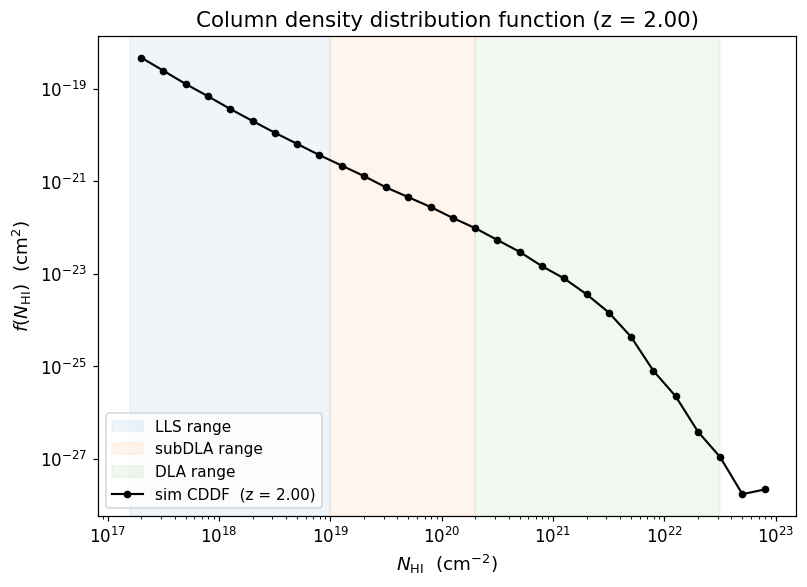

In [4]:
log_nhi_centres = cddf['log_nhi_centres']
f_nhi           = cddf['f_nhi']
n_abs           = cddf['n_absorbers']

mask = f_nhi > 0  # drop empty bins for the log plot

fig, ax = plt.subplots(figsize=(7.5, 5.5))
# Class-range shading (drawn first so curves overlay it).
ax.axvspan(10**17.2, 10**19.0, alpha=0.07, color='C0', label='LLS range')
ax.axvspan(10**19.0, 10**20.3, alpha=0.07, color='C1', label='subDLA range')
ax.axvspan(10**20.3, 10**22.5, alpha=0.07, color='C2', label='DLA range')

ax.loglog(10**log_nhi_centres[mask], f_nhi[mask], 'o-', color='k',
          markersize=4, label=f'sim CDDF  (z = {meta["z"]:.2f})')

ax.set_xlabel(r'$N_{\rm HI}$  (cm$^{-2}$)')
ax.set_ylabel(r'$f(N_{\rm HI})$  (cm$^{2}$)')
ax.set_title(f'Column density distribution function (z = {meta["z"]:.2f})')
ax.legend(loc='lower left')
save_fig(fig, 'NB02_cddf_cached')
plt.show()


## 2. Recompute it from the catalog

The cached file is just the result of running `measure_cddf` on the
catalog.  Recomputing should reproduce it bitwise (modulo numpy
histogram tie-breaking on bin edges, which never matters here):


In [5]:
import pandas as pd
from hcd_analysis.cddf import measure_cddf_from_dataframe

# Build a minimal DataFrame the helper expects
arr_cat = np.load(SNAP_DIR / 'catalog.npz', allow_pickle=True)
df = pd.DataFrame({
    'log_nhi':       np.log10(arr_cat['NHI']),
    'absorber_class': np.where(np.log10(arr_cat['NHI']) >= 20.3, 'DLA',
                       np.where(np.log10(arr_cat['NHI']) >= 19.0, 'subDLA',
                       np.where(np.log10(arr_cat['NHI']) >= 17.2, 'LLS', 'forest'))),
})

# Need cosmology and box from meta.json
ics = meta['sim_ics']
hubble = float(ics['ics_hubble'])
omegam = float(ics['omega0'])
omegal = 1.0 - omegam
box_kpc_h = float(meta['box_kpc_h'])
n_sightlines = int(meta['n_skewers'])

cddf_recompute = measure_cddf_from_dataframe(
    df, z=meta['z'], box_kpc_h=box_kpc_h,
    hubble=hubble, omegam=omegam, omegal=omegal,
    n_sightlines=n_sightlines,
    log_nhi_bins=cddf['log_nhi_edges'],
)

# Compare
diff = cddf_recompute['f_nhi'] - cddf['f_nhi']
ok   = np.allclose(cddf_recompute['f_nhi'], cddf['f_nhi'], rtol=1e-6, atol=0)
print(f'identical to cached: {ok}    max |diff| = {np.max(np.abs(diff)):.3e}')


identical to cached: True    max |diff| = 1.444e-34


**If your recomputation does not match,** the most likely cause is that
the cached `cddf_corrected.npz` was patched in-place from a prior version
with slightly different bin edges.  Always pass the cached `log_nhi_edges`
to `measure_cddf_from_dataframe` (as we did above) so the two grids are
aligned.

## 3. dN/dX per class

dN/dX is the integral of `f(N_HI) · dN` over the NHI range you care
about.  In histogram form it's just the per-bin count divided by
`total_path`:

```
dN/dX | class = sum_{bins in class} counts_bin / total_path
```

which gives the absorbers-per-unit-absorption-path expectation.  Compute
it for each class and compare against the project-wide aggregate file
`hcd_summary_lf.h5`:


In [6]:
import h5py

centres = cddf['log_nhi_centres']
counts  = cddf['n_absorbers']
total_path = float(cddf['total_path'])

dndx_lls    = counts[(centres >= 17.2) & (centres < 19.0)].sum() / total_path
dndx_subdla = counts[(centres >= 19.0) & (centres < 20.3)].sum() / total_path
dndx_dla    = counts[(centres >= 20.3)].sum() / total_path

print('Computed from cddf_corrected.npz:')
print(f'  dN/dX (LLS)    = {dndx_lls:.4f}')
print(f'  dN/dX (subDLA) = {dndx_subdla:.4f}')
print(f'  dN/dX (DLA)    = {dndx_dla:.4f}')

# Cross-check against the project-wide summary
SUMMARY = Path('/scratch/cavestru_root/cavestru0/mfho/hcd_outputs/_hcd_analysis_data/hcd_summary_lf.h5')
if SUMMARY.exists():
    with h5py.File(SUMMARY, 'r') as f:
        sims  = f['sim'][:]
        snaps = f['snap'][:]
        # Find our (sim, snap) row
        target = SIM.encode()
        row = np.where((sims == target) & (snaps == SNAP))[0]
        if row.size:
            i = int(row[0])
            print()
            print('From hcd_summary_lf.h5 row', i, ':')
            for cls in ('LLS', 'subDLA', 'DLA'):
                print(f'  dN/dX ({cls:6s}) = {f[f"dndx/{cls}"][i]:.4f}')
        else:
            print('(this (sim, snap) is not in hcd_summary_lf.h5)')
else:
    print('(summary file not found; skipped cross-check)')


Computed from cddf_corrected.npz:
  dN/dX (LLS)    = 0.2212
  dN/dX (subDLA) = 0.0752
  dN/dX (DLA)    = 0.0320

From hcd_summary_lf.h5 row 87 :
  dN/dX (LLS   ) = 0.2212
  dN/dX (subDLA) = 0.0708
  dN/dX (DLA   ) = 0.0363


Expected agreement, with one subtlety:

* **LLS** should match the summary file exactly (the lower class
  boundary at log NHI = 17.2 is also the catalog's minimum, and the
  upper boundary at 19.0 *is* a bin edge of the 30-bin CDDF grid).
* **subDLA** and **DLA** will typically differ from the summary file
  at the **~5–15 %** level.  This is **not** a bug — it's a binning
  artifact.  The histogram-summation we did here counts absorbers in
  whole `log NHI` bins, but the class boundaries 19.0 and 20.3 do not
  fall on bin edges, so absorbers in the boundary bins get
  mis-attributed.  The summary file (`hcd_summary_lf.h5`) computes
  per-class counts directly from each absorber's `log10(NHI)` —
  ungridded, exact — and is therefore the authoritative value.

In short: **for class statistics, classify by absorber NHI, not by
binned CDDF**.  We computed it both ways here on purpose to make this
point explicit; the histogram form is convenient for plotting `f(N_HI)`
but is not exact for `dN/dX` per class.

## 4. Compare against Ho+21

The Ho+21 CDDF tables live at `/home/mfho/DLA_data/ho21/`.  At z = 2.2
the closest table is `cddf_z225.txt`.  We overplot to check the sim
follows the observed CDDF roughly: at the DLA range the sim and the
data agree to within a factor of a few, but **LLS and sub-DLAs tend to
be over-predicted by current PRIYA-class sims**.

Two physical reasons this happens (both contribute, neither is
quantitatively settled):

1. **UV background amplitude.**  The CDDF at log NHI ≈ 17.2–19 is set
   by the photoionisation rate `Γ_UV` of the meta-galactic UV
   background.  PRIYA uses a Faucher-Giguère 2020 (or similar) UVB
   prescription; if the true UVB is stronger at z ~ 2–3 than that
   prescription says, real sightlines are more ionised and the
   observed sub-DLA count drops.  See `docs/analysis.md` and the
   FG'20 background papers for the prescription details.
2. **Small-scale structure / sub-grid clumping.**  At PRIYA's
   resolution (`Mpc/h` scale), the self-shielded LLS column is only
   marginally resolved; sub-grid treatments of clumping and
   self-shielding affect the column distribution at log NHI ≈ 17–19
   strongly.  Higher-resolution runs (the HR set) typically lower the
   LLS prediction by 0.1–0.3 dex without changing the DLA prediction
   much, which is the signature of a resolution effect rather than a
   cosmological one.

This is exactly the figure that `scripts/plot_cddf_vs_ho21.py` produces
for all four redshift bins; here we do just the one corresponding to our
chosen snap.


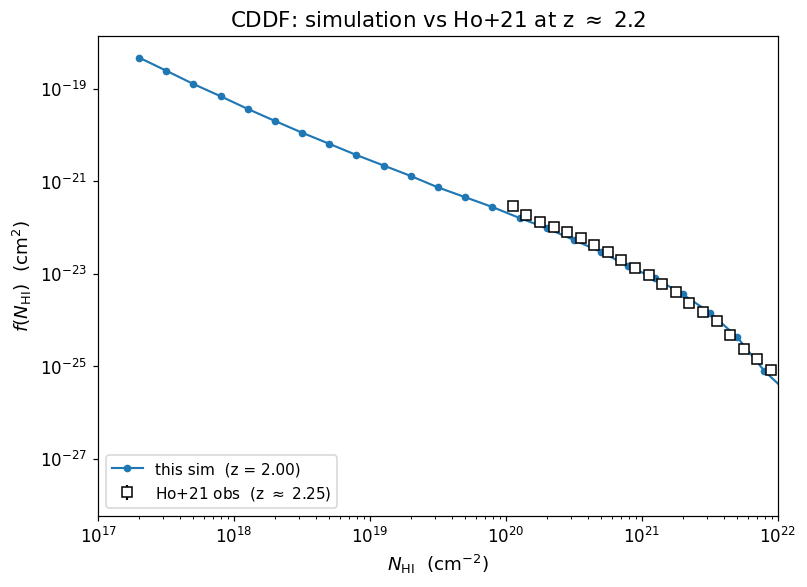

In [7]:
HO21 = Path('/home/mfho/DLA_data/ho21/cddf_z225.txt')
fig, ax = plt.subplots(figsize=(7.5, 5.5))

# Sim curve from cache
ax.loglog(10**log_nhi_centres[mask], f_nhi[mask], 'o-', color='C0',
          markersize=4, label=f'this sim  (z = {meta["z"]:.2f})')

# Ho+21
if HO21.exists():
    # File is row-major: row 0 = log NHI centres, row 1 = f central,
    # row 2 = lo68, row 3 = hi68.  Drop bins where central value is 0.
    ho21 = np.loadtxt(HO21)
    logN, fcen, flo, fhi = ho21[0], ho21[1], ho21[2], ho21[3]
    ok = np.isfinite(fcen) & (fcen > 0)
    logN, fcen, flo, fhi = logN[ok], fcen[ok], flo[ok], fhi[ok]
    yerr_lo = np.clip(fcen - flo, 0, fcen * 0.999)
    yerr_hi = np.clip(fhi - fcen, 0, None)
    ax.errorbar(10**logN, fcen, yerr=[yerr_lo, yerr_hi],
                fmt='ks', mfc='white', markersize=6,
                label=r'Ho+21 obs  (z $\approx$ 2.25)')
else:
    print('Ho+21 reference file not found at', HO21, '— skipping overlay.')

ax.set_xlim(1e17, 1e22)  # clip to the LLS-DLA range where both curves are defined
ax.set_xlabel(r'$N_{\rm HI}$  (cm$^{-2}$)')
ax.set_ylabel(r'$f(N_{\rm HI})$  (cm$^{2}$)')
ax.set_title(r'CDDF: simulation vs Ho+21 at z $\approx$ 2.2')
ax.legend(loc='lower left')
save_fig(fig, 'NB02_cddf_vs_ho21')
plt.show()


## Suggested student exercises

1. **Different (sim, snap).**  Repeat the recomputation for a different
   simulation and a different snapshot.  Pick something at z = 3 (snap
   017) or z = 4 (snap 010) and overplot Ho+21 at the matching redshift
   (`cddf_z34.txt`, `cddf_z45.txt`).
2. **Stack across sims.**  Load `cddf_corrected.npz` for all 60 LF sims
   at one snap and compute the median CDDF and its 16/84-percentile
   spread.  This is the within-LHS scatter at fixed redshift; visualise it.
3. **dN/dX(z).**  For one sim, plot dN/dX (DLA) as a function of redshift
   (snaps 4 → 23).  Compare against PRIYA papers (Bird et al. 2017).

These exercises are good warm-ups for the emulator work, where the
inputs *are* CDDFs and dN/dX values across the whole (sim, snap)
ensemble.
